In [1]:
# Testing

In [3]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore", category=FutureWarning, message=".*use_inf_as_na.*")

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

In [4]:
import kagglehub
import shutil
import os

# Download latest version
path = kagglehub.dataset_download("datasetengineer/eviot-predictivemaint-dataset")

print("Path to dataset files:", path)

# Move the dataset to the data/ folder
if os.path.exists('data'):
    shutil.rmtree('data')  # Remove existing data folder if any
shutil.copytree(path, 'data')

print("Dataset moved to data/ folder.")

Path to dataset files: /Users/noam/.cache/kagglehub/datasets/datasetengineer/eviot-predictivemaint-dataset/versions/1
Dataset moved to data/ folder.


In [5]:
# df = pd.read_csv("data/synthetic_ev_battery_5year_50cols_multimfg_3M.csv")
df = pd.read_csv('data/EV_Predictive_Maintenance_Dataset_15min.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head() 

Shape: (175393, 30)

Column dtypes:
float64    27
int64       2
str         1
Name: count, dtype: int64

Missing values:
Series([], dtype: int64)


,Timestamp,SoC,SoH,Battery_Voltage,Battery_Current,Battery_Temperature,Charge_Cycles,Motor_Temperature,Motor_Vibration,Motor_Torque,...,Load_Weight,Driving_Speed,Distance_Traveled,Idle_Time,Route_Roughness,RUL,Failure_Probability,Maintenance_Type,TTF,Component_Health_Score
0,2020-01-01 00:00:00,0.826099,0.941338,210.163881,-22.753095,27.149201,149.190930,48.496049,0.369095,113.435589,...,741.754518,103.421162,66.232383,0.520922,0.225970,260.503381,0,1,111.116697,0.852745
1,2020-01-01 00:15:00,0.064728,0.916059,364.000102,-27.701120,53.655101,171.702388,57.829492,1.449195,105.587160,...,769.134035,46.041935,3.146238,0.844005,0.204350,212.813954,0,2,179.229425,0.827616
2,2020-01-01 00:30:00,0.873643,0.908020,388.855089,-36.646406,29.559090,191.617645,46.518363,1.859045,119.610302,...,917.262931,59.588422,79.909148,0.992405,0.175125,273.394511,0,1,171.852663,0.876887
3,2020-01-01 00:45:00,0.853009,0.916476,370.570602,-37.609429,29.690283,111.881817,54.163681,0.381500,182.535625,...,600.598736,44.222285,0.774000,0.007615,0.213264,229.508442,0,0,165.221328,0.816290
4,2020-01-01 01:00:00,0.947540,0.913206,390.011904,-14.275808,28.864338,163.774377,42.075978,0.433927,173.298044,...,613.153029,41.374684,2.872124,0.771938,0.770257,257.302631,1,0,176.890659,0.744260


In [ ]:
# Drop leakage + useless columns #MAY NEED TO CHANGE WITH NEW DATASET
drop_cols = [
    "capacity_fade_%",                    # inverse of SOH
    "resistance_growth_%",                # SOH-derived
    "degradation_rate_%",                 # SOH-derived  
    "effective_energy_density_Wh_per_kg", # SOH-adjusted
    "cell_id",                            # meaningless (only 1 unique value)
    "timestamp",                          # string, cycle_number already captures time
]

# Encode categorical columns
df_model = pd.get_dummies(df.drop(columns=drop_cols), 
                          columns=["manufacturer", "chemistry_type"], 
                          drop_first=True)

# Define features and target
target = "state_of_health_%"
X = df_model.drop(columns=[target])
y = df_model[target]

print(f"Features: {X.shape[1]}")
print(f"Sample size: {X.shape[0]}")
print(X.columns.tolist())

Features: 47
Sample size: 3000000
['nominal_capacity_Ah', 'nominal_voltage_V', 'energy_density_Wh_per_kg', 'energy_density_Wh_per_L', 'manufacture_year', 'cycle_number', 'voltage_V', 'current_A', 'power_W', 'c_rate', 'state_of_charge_%', 'depth_of_discharge_%', 'charge_capacity_Ah', 'discharge_capacity_Ah', 'coulombic_efficiency_%', 'internal_resistance_mOhm', 'dynamic_resistance_mOhm', 'open_circuit_voltage_V', 'cell_temperature_C', 'ambient_temperature_C', 'temperature_gradient_C', 'heat_generation_W', 'cooling_flow_rate', 'thermal_runaway_risk_index', 'max_temp_limit_C', 'calendar_age_days', 'cycle_age', 'energy_throughput_kWh', 'max_current_limit_A', 'min_current_limit_A', 'max_voltage_limit_V', 'min_voltage_limit_V', 'min_temp_limit_C', 'safety_margin_index', 'overcurrent_flag', 'undercurrent_flag', 'over_voltage_flag', 'under_voltage_flag', 'over_temperature_flag', 'under_temperature_flag', 'short_circuit_flag', 'manufacturer_FutureCharge Inc', 'manufacturer_GreenLithium Tech', '

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # use fit from train only

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")

Train size: 2,400,000
Test size:  600,000


In [ ]:
# Check if charge/discharge capacity directly encodes SOH
print(df[["charge_capacity_Ah", "discharge_capacity_Ah", 
          "nominal_capacity_Ah", "state_of_health_%"]].head(10))

# SOH is defined as measured_capacity / nominal_capacity * 100
# If this correlation is ~1.0, these are leakage
print(df["discharge_capacity_Ah"].corr(df["state_of_health_%"]))
print(df["cycle_age"].corr(df["cycle_number"]))  # likely redundant

   charge_capacity_Ah  discharge_capacity_Ah  nominal_capacity_Ah  \
0            3.199591               3.199591                  3.2   
1            3.199988               3.199988                  3.2   
2            3.199909               3.199909                  3.2   
3            3.199930               3.199930                  3.2   
4            3.199874               3.199874                  3.2   
5            3.199733               3.199733                  3.2   
6            3.199812               3.199812                  3.2   
7            3.199483               3.199483                  3.2   
8            3.199369               3.199369                  3.2   
9            3.199949               3.199949                  3.2   

   state_of_health_%  
0          99.987215  
1          99.999628  
2          99.997165  
3          99.997817  
4          99.996075  
5          99.991645  
6          99.994122  
7          99.983857  
8          99.980271  
9         

In [ ]:
# Confirmed leakage - all correlate at 1.0 with target
extra_drop = ["charge_capacity_Ah", "discharge_capacity_Ah", "cycle_age"]

X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns).drop(columns=extra_drop)
X_test_final  = pd.DataFrame(X_test_scaled,  columns=X_test.columns).drop(columns=extra_drop)

print(f"Final feature count: {X_train_final.shape[1]}")
print(X_train_final.columns.tolist())

Final feature count: 44
['nominal_capacity_Ah', 'nominal_voltage_V', 'energy_density_Wh_per_kg', 'energy_density_Wh_per_L', 'manufacture_year', 'cycle_number', 'voltage_V', 'current_A', 'power_W', 'c_rate', 'state_of_charge_%', 'depth_of_discharge_%', 'coulombic_efficiency_%', 'internal_resistance_mOhm', 'dynamic_resistance_mOhm', 'open_circuit_voltage_V', 'cell_temperature_C', 'ambient_temperature_C', 'temperature_gradient_C', 'heat_generation_W', 'cooling_flow_rate', 'thermal_runaway_risk_index', 'max_temp_limit_C', 'calendar_age_days', 'energy_throughput_kWh', 'max_current_limit_A', 'min_current_limit_A', 'max_voltage_limit_V', 'min_voltage_limit_V', 'min_temp_limit_C', 'safety_margin_index', 'overcurrent_flag', 'undercurrent_flag', 'over_voltage_flag', 'under_voltage_flag', 'over_temperature_flag', 'under_temperature_flag', 'short_circuit_flag', 'manufacturer_FutureCharge Inc', 'manufacturer_GreenLithium Tech', 'manufacturer_PowerNova Systems', 'manufacturer_VoltCore Energy', 'chem

In [ ]:
# Train
model = LinearRegression()
model.fit(X_train_final, y_train)
print("Model trained")

# Evaluate
y_pred = model.predict(X_test_final)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR²   : {r2:.4f}    (1.0 = perfect)")
print(f"MAE  : {mae:.4f}  (avg error in % SOH)")
print(f"RMSE : {rmse:.4f}  (penalises large errors)")

Model trained

R²   : 1.0000    (1.0 = perfect)
MAE  : 0.0000  (avg error in % SOH)
RMSE : 0.0000  (penalises large errors)


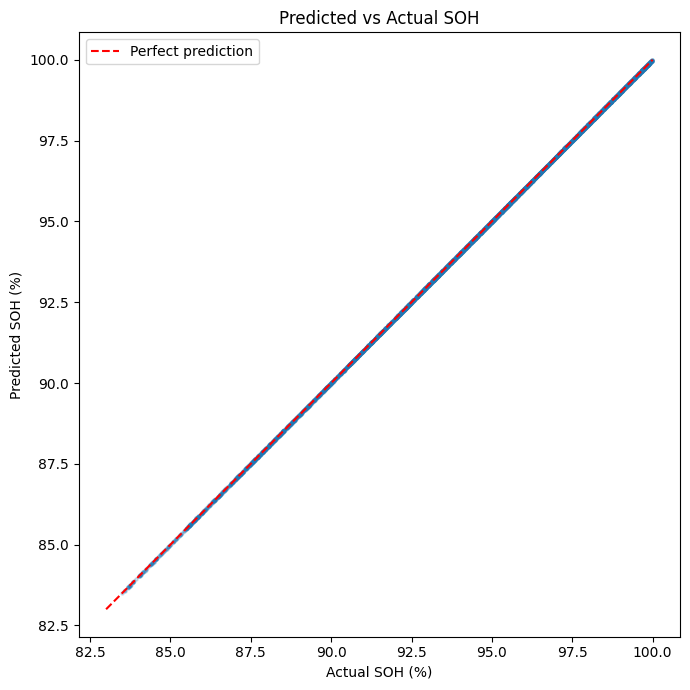

In [ ]:
# Predicted vs actual plot
sample = np.random.choice(len(y_test), 5000, replace=False)
y_test_arr = np.array(y_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test_arr[sample], y_pred[sample], alpha=0.2, s=5)
plt.plot([83, 100], [83, 100], "r--", label="Perfect prediction")
plt.xlabel("Actual SOH (%)")
plt.ylabel("Predicted SOH (%)")
plt.title("Predicted vs Actual SOH")
plt.legend()
plt.tight_layout()
plt.show()